# EDA — Gold layer (feature store + label store)

* **Features**: `datamart/gold/features_store`, one row per customer at application time (`snapshot_date` = loan start).
* **Labels**: `datamart/gold/label_store`, `label` = 30 dpd at 6 mob. Its `snapshot_date` is the **label date** = loan start + 6 months.
* **Join**: `features.customer_id = labels.customer_id` and `features.snapshot_date = labels.snapshot_date - 6 months` (same join as `model_training.ipynb`).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')
GOLD = 'datamart/gold'
LABEL_MOB = 6
FE = [f'fe_{i}' for i in range(1, 21)]
CATEGORICAL = ['occupation', 'credit_mix', 'payment_of_min_amount', 'payment_behaviour']

## 1. Load and join

In [10]:
features = pd.read_parquet(f'{GOLD}/features_store')
labels = pd.read_parquet(f'{GOLD}/label_store')
print('features', features.shape, '| labels', labels.shape)
print('feature snapshot', features['snapshot_date'].min(), '->', features['snapshot_date'].max())
print('label snapshot  ', labels['snapshot_date'].min(), '->', labels['snapshot_date'].max())
print('label_def', labels['label_def'].unique())

features['snapshot_date'] = pd.to_datetime(features['snapshot_date'])
labels = labels[['loan_id', 'customer_id', 'label', 'snapshot_date']].rename(columns={'snapshot_date': 'label_date'})
labels['label_date'] = pd.to_datetime(labels['label_date'])
labels['loan_start_date'] = labels['label_date'] - pd.DateOffset(months=LABEL_MOB)

assert not features.duplicated(['customer_id', 'snapshot_date']).any()
assert labels['loan_id'].is_unique
df = features.merge(labels, left_on=['customer_id', 'snapshot_date'],
                    right_on=['customer_id', 'loan_start_date'], how='inner')
assert len(df) == len(labels) == len(features), 'join should be 1:1'
print('joined', df.shape, '| customers', df['customer_id'].nunique())

features (12500, 44) | labels (12500, 5)
feature snapshot 2023-01-01 -> 2025-01-01
label snapshot   2023-07-01 -> 2025-07-01
label_def ['30dpd_6mob']
joined (12500, 48) | customers 12500


In [11]:
NUMERIC = [c for c in features.select_dtypes('number').columns if c not in FE]
print(len(NUMERIC), 'numeric profile/financial,', len(CATEGORICAL), 'categorical,', len(FE), 'clickstream, + type_of_loan')
df.head()

17 numeric profile/financial, 4 categorical, 20 clickstream, + type_of_loan


,customer_id,snapshot_date,age,occupation,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,type_of_loan,delay_from_due_date,num_of_delayed_payment,changed_credit_limit,num_credit_inquiries,credit_mix,outstanding_debt,credit_utilization_ratio,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,monthly_balance,credit_history_months,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,loan_id,label,label_date,loan_start_date
0,CUS_0x1037,2023-01-01,45.0,Accountant,15989.080078,1086.420044,5.0,4.0,2.0,4.0,"Credit-Builder Loan, Auto Loan, Auto Loan, and...",13.0,15.0,0.50,3.0,Good,665.820007,40.697701,No,33.797020,80.465240,Low_spent_Small_value_payments,284.380127,237,63.0,118.0,80.0,121.0,55.0,193.0,111.0,112.0,-101.0,83.0,164.0,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,CUS_0x1037_2023_01_01,0,2023-07-01,2023-01-01
1,CUS_0x1069,2023-01-01,32.0,Accountant,58637.339844,4799.439941,4.0,6.0,10.0,3.0,"Personal Loan, Auto Loan, and Not Specified",9.0,17.0,12.56,5.0,Standard,208.800003,25.233143,Yes,139.885010,165.210617,High_spent_Small_value_payments,434.848877,368,-108.0,182.0,123.0,4.0,-56.0,27.0,25.0,-6.0,284.0,222.0,203.0,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,CUS_0x1069_2023_01_01,0,2023-07-01,2023-01-01
2,CUS_0x114a,2023-01-01,43.0,Developer,15305.459961,1230.449951,0.0,7.0,2.0,2.0,"Student Loan, and Home Equity Loan",14.0,2.0,15.95,0.0,Good,642.419983,27.525112,No,20.301655,64.778481,Low_spent_Small_value_payments,327.965363,189,-13.0,8.0,87.0,166.0,214.0,-98.0,215.0,152.0,129.0,139.0,14.0,203.0,26.0,86.0,171.0,125.0,-130.0,354.0,17.0,302.0,CUS_0x114a_2023_01_01,0,2023-07-01,2023-01-01
3,CUS_0x1184,2023-01-01,49.0,Lawyer,19867.470703,1396.619995,3.0,5.0,11.0,3.0,"Student Loan, Mortgage Loan, and Payday Loan",10.0,9.0,6.74,4.0,Good,707.289978,26.689791,No,42.606880,23.460943,None,313.594452,392,-85.0,45.0,200.0,89.0,128.0,54.0,76.0,51.0,61.0,139.0,6.0,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,CUS_0x1184_2023_01_01,0,2023-07-01,2023-01-01
4,CUS_0x1297,2023-01-01,46.0,Manager,57738.058594,4881.500000,9.0,8.0,30.0,9.0,"Payday Loan, Personal Loan, Payday Loan, Perso...",61.0,24.0,14.27,11.0,Bad,3916.469971,25.742142,Yes,296.284149,53.821178,High_spent_Medium_value_payments,388.045197,164,55.0,120.0,226.0,-86.0,253.0,97.0,107.0,68.0,103.0,126.0,34.0,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,CUS_0x1297_2023_01_01,1,2023-07-01,2023-01-01


In [16]:
df['occupation'].unique()

array(['Accountant', 'Developer', 'Lawyer', 'Manager', 'Doctor',
       'Mechanic', 'Journalist', 'Media_Manager', 'Teacher',
       'Entrepreneur', 'Writer', 'Musician', 'Engineer', None,
       'Scientist', 'Architect'], dtype=object)

## 2. Target

overall default rate: 0.288  (3602 / 12500)


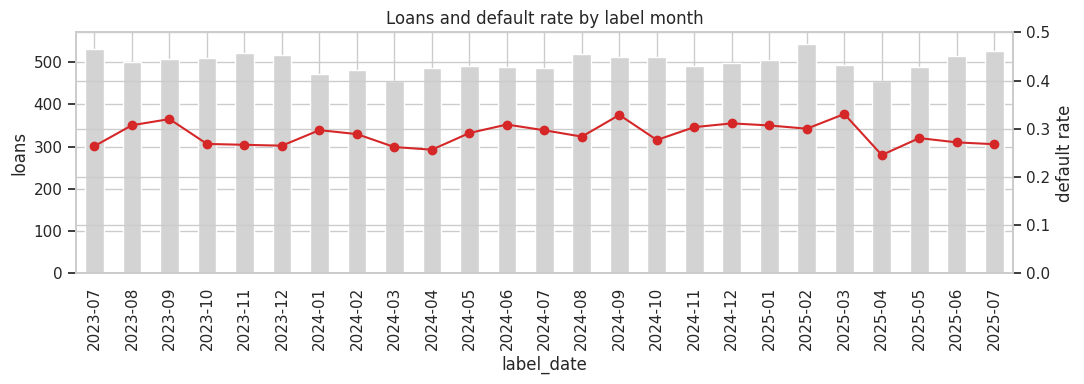

label_date,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
size,530.000,501.000,506.00,510.000,521.000,517.000,471.000,481.000,454.000,487.000,491.000,489.000,485.000,518.000,511.000,513.000,491.000,498.000,505.000,543.0,493.000,456.000,488.000,515.000,526.000
mean,0.264,0.307,0.32,0.269,0.267,0.265,0.297,0.289,0.262,0.257,0.291,0.309,0.297,0.284,0.329,0.277,0.303,0.311,0.307,0.3,0.331,0.246,0.281,0.272,0.268


In [6]:
print(f"overall default rate: {df['label'].mean():.3f}  ({df['label'].sum()} / {len(df)})")
m = df.groupby(df['label_date'].dt.to_period('M'))['label'].agg(['size', 'mean'])
fig, ax = plt.subplots(figsize=(11, 4))
m['size'].plot.bar(ax=ax, color='lightgrey', label='loans')
ax2 = ax.twinx()
ax2.plot(range(len(m)), m['mean'], 'o-', color='tab:red', label='default rate')
ax2.set_ylim(0, 0.5); ax.set_ylabel('loans'); ax2.set_ylabel('default rate')
ax.set_title('Loans and default rate by label month'); plt.tight_layout(); plt.show()
m.T.round(3)

## 3. Missing values
Is missingness itself predictive? Compare default rate when a column is missing vs present.

In [7]:
miss = pd.DataFrame({
    'missing_pct': df.isna().mean(),
    'default_if_missing': {c: df.loc[df[c].isna(), 'label'].mean() for c in df},
    'default_if_present': {c: df.loc[df[c].notna(), 'label'].mean() for c in df},
})
miss = miss[miss['missing_pct'] > 0].sort_values('missing_pct', ascending=False)
miss.round(3)

,missing_pct,default_if_missing,default_if_present
fe_3,0.282,0.287,0.289
fe_12,0.282,0.287,0.289
fe_6,0.282,0.287,0.289
fe_7,0.282,0.287,0.289
fe_8,0.282,0.287,0.289
fe_9,0.282,0.287,0.289
fe_10,0.282,0.287,0.289
fe_11,0.282,0.287,0.289
fe_13,0.282,0.287,0.289
fe_4,0.282,0.287,0.289


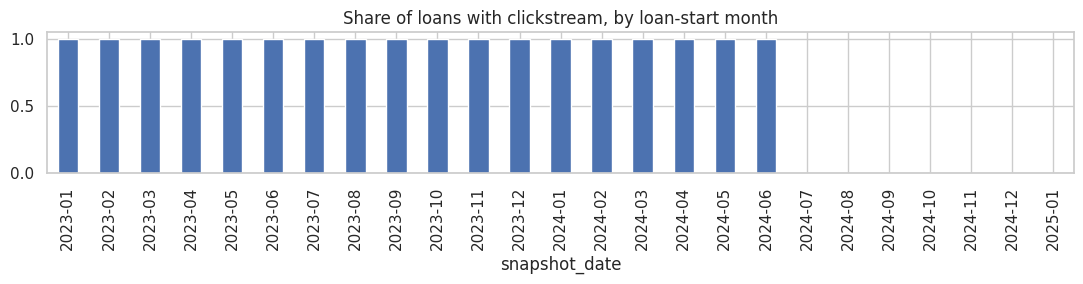

In [12]:
# clickstream missingness is purely time-driven: clickstream data stops at 2024-12
cov = df.groupby(df['snapshot_date'].dt.to_period('M'))['fe_1'].apply(lambda s: s.notna().mean())
cov.plot.bar(figsize=(11, 3), title='Share of loans with clickstream, by loan-start month', ylim=(0, 1.05))
plt.tight_layout(); plt.show()

## 4. Numeric features — distributions and outliers

In [ ]:
desc = df[NUMERIC].describe(percentiles=[.01, .5, .99]).T
desc['skew'] = df[NUMERIC].skew()
desc['max / p99'] = desc['max'] / desc['99%']
desc.round(2)

,count,mean,std,min,1%,50%,99%,max,skew,max / p99
age,12181.0,33.62,10.77,14.00,15.00,33.00,55.00,56.00,0.15,1.02
annual_income,12500.0,161620.55,1297841.62,7005.93,7542.44,37572.38,178815.71,23834698.00,12.76,133.29
monthly_inhand_salary,12500.0,4188.59,3180.15,303.65,531.87,3087.59,13789.24,15204.63,1.13,1.10
num_bank_accounts,12329.0,5.37,2.59,0.00,0.00,5.00,10.00,11.00,-0.19,1.10
num_credit_card,12204.0,5.54,2.07,0.00,1.00,5.00,10.00,11.00,0.23,1.10
interest_rate,12230.0,14.56,8.75,1.00,1.00,13.00,34.00,34.00,0.49,1.00
num_of_loan,12438.0,3.56,2.48,0.00,0.00,3.00,9.00,33.00,0.74,3.67
delay_from_due_date,12412.0,21.23,14.78,0.00,0.00,18.00,61.00,67.00,0.98,1.10
num_of_delayed_payment,12311.0,13.41,6.21,0.00,0.00,14.00,25.00,28.00,-0.17,1.12
changed_credit_limit,12246.0,10.40,6.80,-6.49,-1.84,9.41,28.80,36.97,0.63,1.28


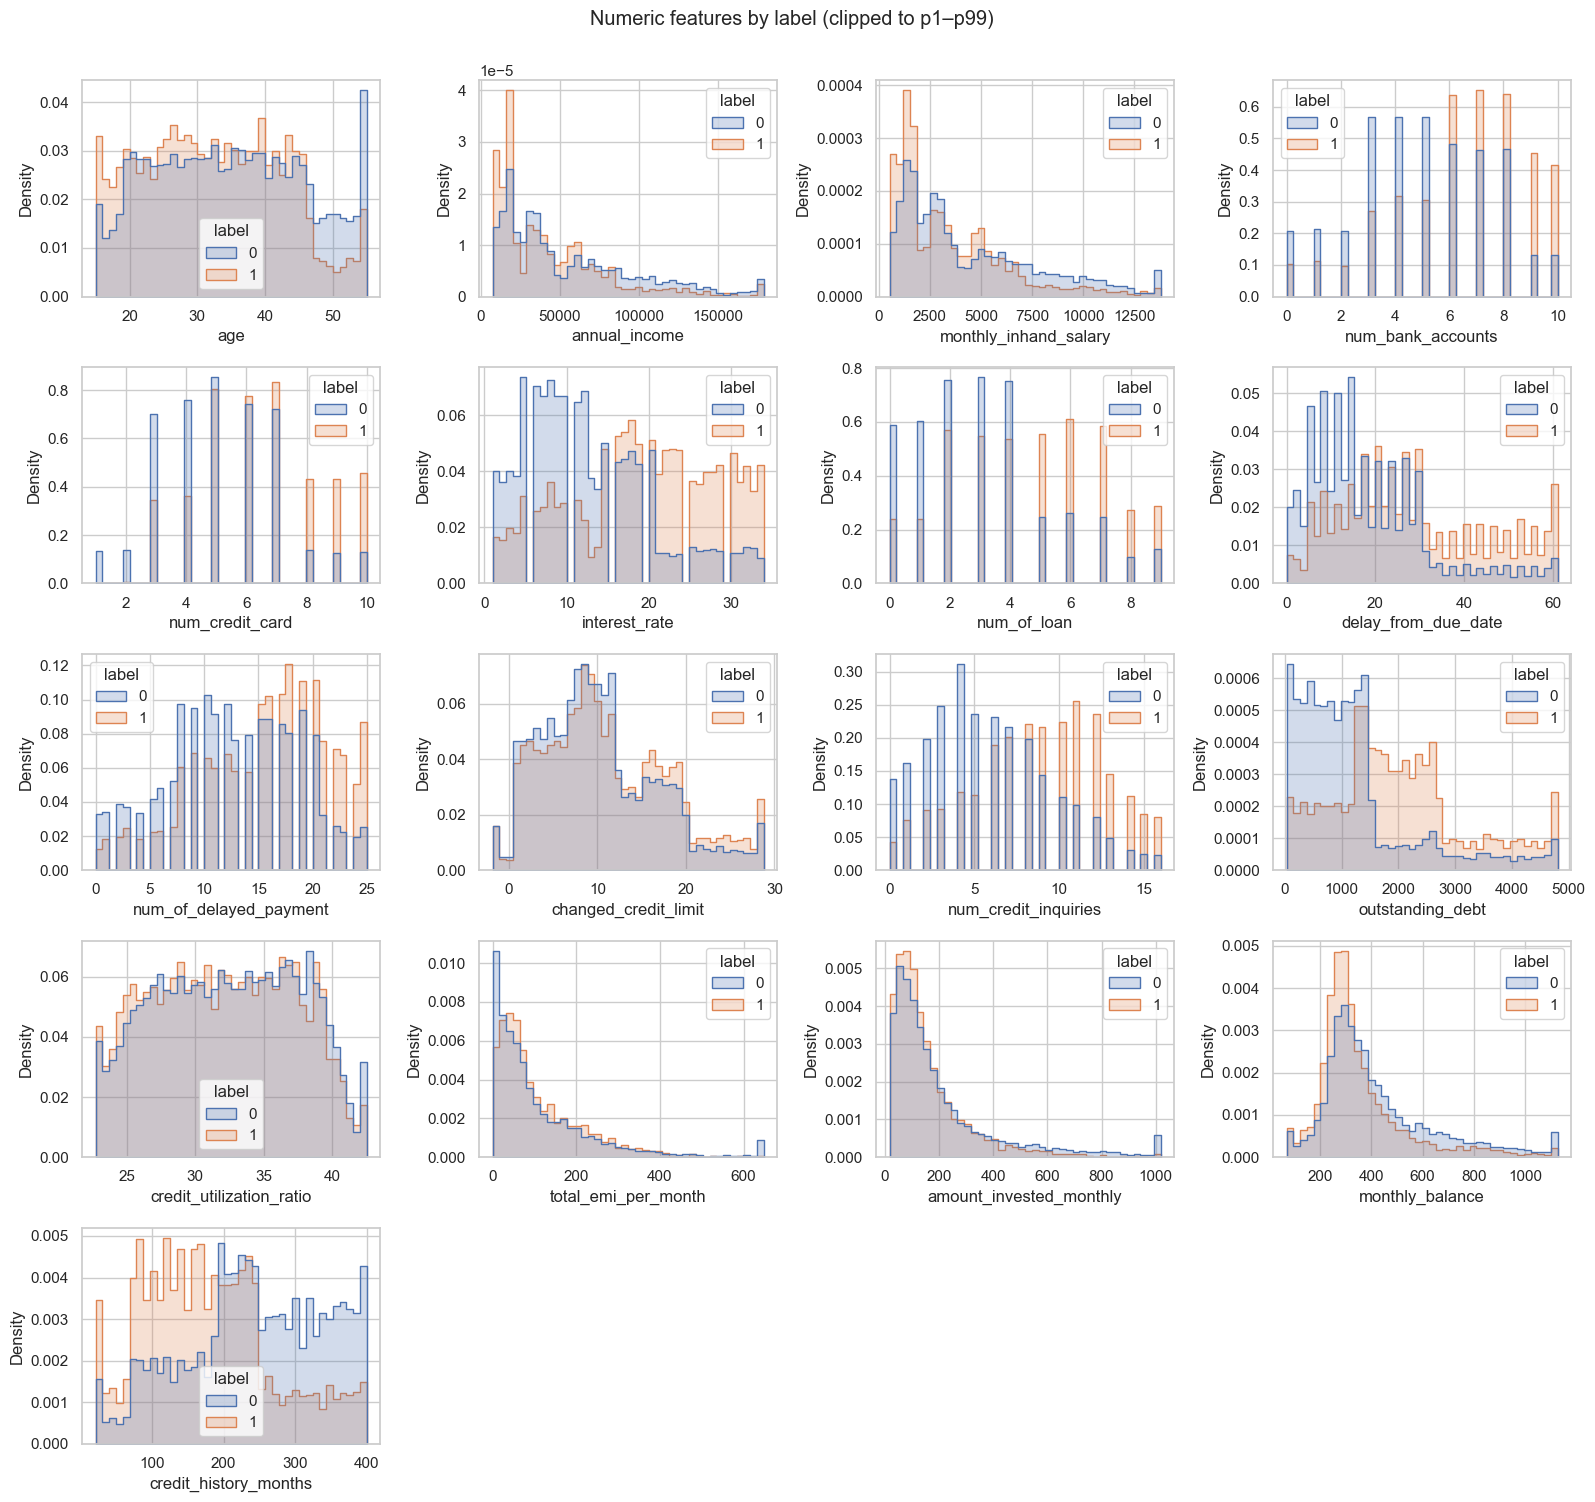

In [ ]:
# clip to p1/p99 for plotting only, so the extreme tails don't flatten the histograms
clip = df[NUMERIC].clip(df[NUMERIC].quantile(.01), df[NUMERIC].quantile(.99), axis=1)
n = len(NUMERIC); cols = 4
fig, axes = plt.subplots(-(-n // cols), cols, figsize=(16, 3 * -(-n // cols)))
for ax, c in zip(axes.flat, NUMERIC):
    sns.histplot(data=clip.assign(label=df['label']), x=c, hue='label', stat='density',
                 common_norm=False, element='step', bins=40, ax=ax)
for ax in axes.flat[n:]:
    ax.remove()
plt.suptitle('Numeric features by label (clipped to p1–p99)', y=1.0); plt.tight_layout(); plt.show()

## 5. Numeric features vs target
**Univariate AUC** of each raw feature (NaN rows dropped). 0.5 = no signal; below 0.5 means higher values → lower risk. `strength = |AUC - 0.5|`.

In [ ]:
def uni_auc(cols):
    out = {}
    for c in cols:
        s = df[[c, 'label']].dropna()
        auc = roc_auc_score(s['label'], s[c])
        out[c] = {'auc': auc, 'strength': abs(auc - 0.5), 'n': len(s),
                  'mean_label0': s.loc[s['label'] == 0, c].median(), 'mean_label1': s.loc[s['label'] == 1, c].median()}
    return pd.DataFrame(out).T.rename(columns={'mean_label0': 'median_label0', 'mean_label1': 'median_label1'}) \
             .sort_values('strength', ascending=False)

uni_num = uni_auc(NUMERIC)
uni_num.round(3)

,auc,strength,n,median_label0,median_label1
outstanding_debt,0.728,0.228,12500.0,947.360,1826.385
interest_rate,0.721,0.221,12230.0,11.000,20.000
num_credit_inquiries,0.708,0.208,12305.0,5.000,9.000
delay_from_due_date,0.695,0.195,12412.0,15.000,26.000
credit_history_months,0.310,0.190,12500.0,243.000,169.500
num_credit_card,0.679,0.179,12204.0,5.000,6.000
num_of_loan,0.672,0.172,12438.0,3.000,5.000
num_bank_accounts,0.666,0.166,12329.0,5.000,7.000
num_of_delayed_payment,0.642,0.142,12311.0,12.000,16.000
monthly_balance,0.392,0.108,12499.0,357.380,304.586


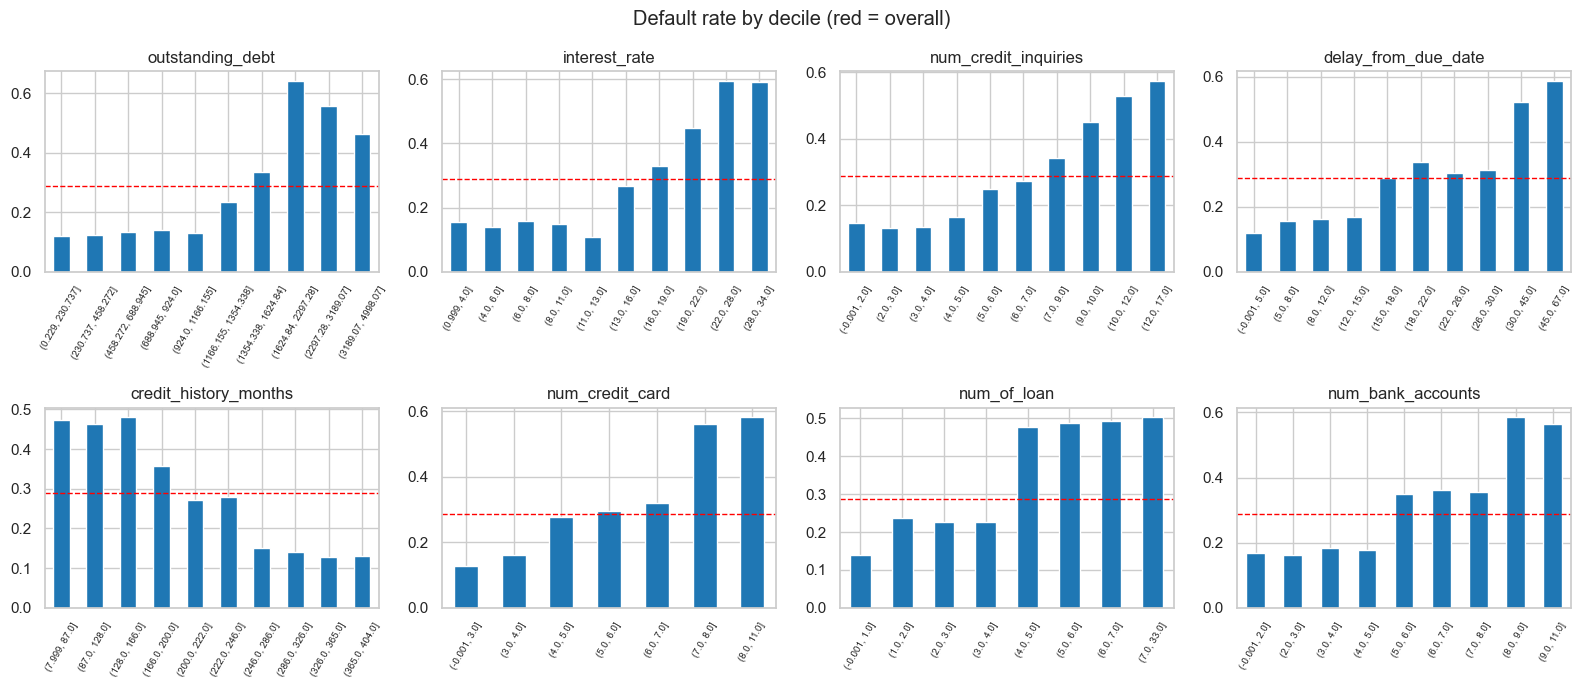

In [ ]:
# default rate by decile for the 8 strongest numeric features
top = uni_num.index[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, top):
    q = pd.qcut(df[c], 10, duplicates='drop')
    df.groupby(q, observed=True)['label'].mean().plot.bar(ax=ax, color='tab:blue')
    ax.axhline(df['label'].mean(), color='red', ls='--', lw=1)
    ax.set_title(c); ax.set_xlabel(''); ax.tick_params(axis='x', labelsize=7, rotation=60)
plt.suptitle('Default rate by decile (red = overall)'); plt.tight_layout(); plt.show()

## 6. Categorical features vs target

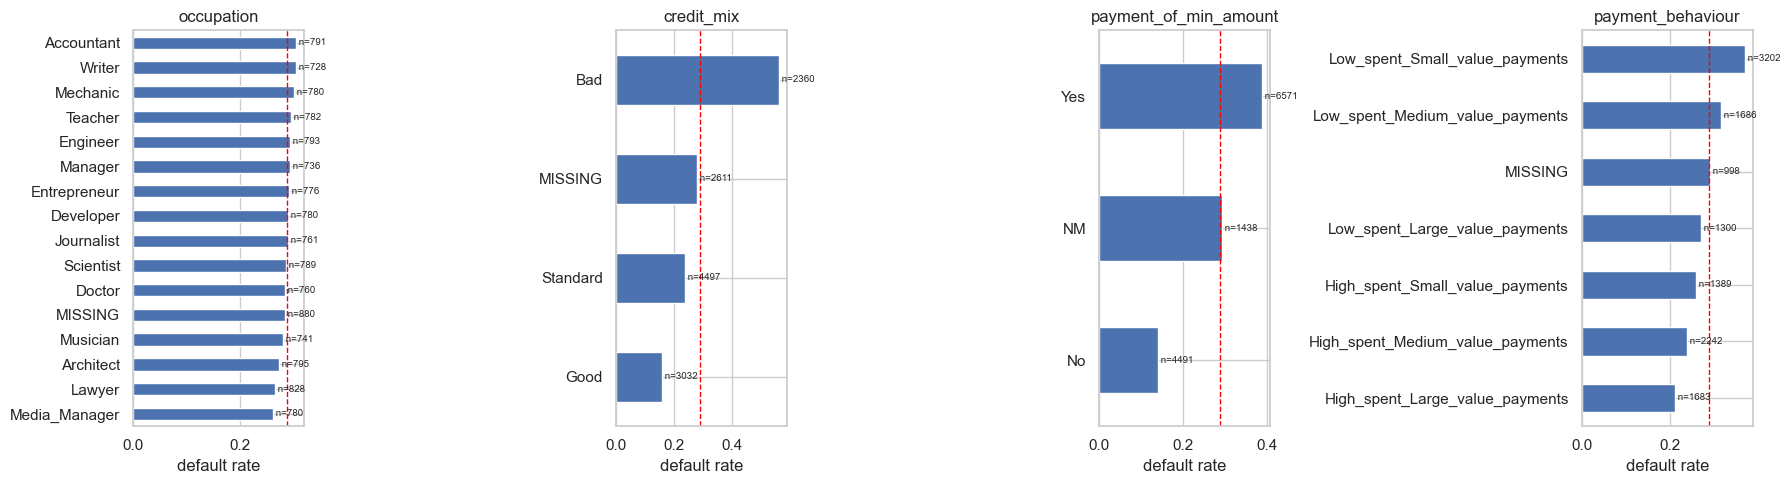

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, c in zip(axes, CATEGORICAL):
    g = df.groupby(df[c].fillna('MISSING'))['label'].agg(['size', 'mean']).sort_values('mean')
    g['mean'].plot.barh(ax=ax)
    ax.axvline(df['label'].mean(), color='red', ls='--', lw=1)
    for i, (sz, r) in enumerate(zip(g['size'], g['mean'])):
        ax.text(r, i, f' n={sz}', va='center', fontsize=7)
    ax.set_title(c); ax.set_xlabel('default rate'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [ ]:
# Cramér's V: strength of association between each categorical and the label
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    t = pd.crosstab(x, y); chi2 = chi2_contingency(t)[0]
    return np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))
pd.Series({c: cramers_v(df[c].fillna('MISSING'), df['label']) for c in CATEGORICAL}).sort_values(ascending=False).round(3)

credit_mix               0.305
payment_of_min_amount    0.252
payment_behaviour        0.125
occupation               0.027
dtype: float64

## 7. `type_of_loan`
Free-text list (`'Auto Loan, Personal Loan, and Mortgage Loan'`). Split into one row per loan type.

In [ ]:
types = (df[['loan_id', 'label', 'type_of_loan']]
         .assign(t=df['type_of_loan'].str.replace(', and ', ', ').str.replace('and ', '').str.split(', '))
         .explode('t'))
types['t'] = types['t'].fillna('MISSING')
# a customer can hold the same type twice; count each type once per loan
per_type = types.drop_duplicates(['loan_id', 't']).groupby('t')['label'].agg(['size', 'mean']).sort_values('mean')
print('loan types per customer:', df['type_of_loan'].str.count(',').add(1).describe().round(2).to_dict())
per_type.round(3)

loan types per customer: {'count': 11074.0, 'mean': 3.99, 'std': 2.22, 'min': 1.0, '25%': 2.0, '50%': 4.0, '75%': 6.0, 'max': 9.0}


,size,mean
t,,
MISSING,1426,0.137
Payday Loan,3993,0.358
Personal Loan,3888,0.359
Not Specified,3960,0.360
Debt Consolidation Loan,3880,0.360
Mortgage Loan,3920,0.360
Home Equity Loan,3925,0.362
Credit-Builder Loan,3966,0.366
Auto Loan,3820,0.368


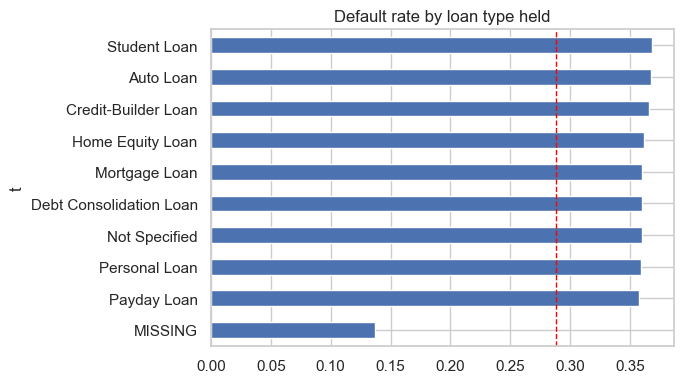

In [ ]:
ax = per_type['mean'].plot.barh(figsize=(7, 4), title='Default rate by loan type held')
ax.axvline(df['label'].mean(), color='red', ls='--', lw=1); plt.tight_layout(); plt.show()

## 8. Correlation between numeric features
Spearman (rank) correlation, robust to the heavy tails seen in section 4.

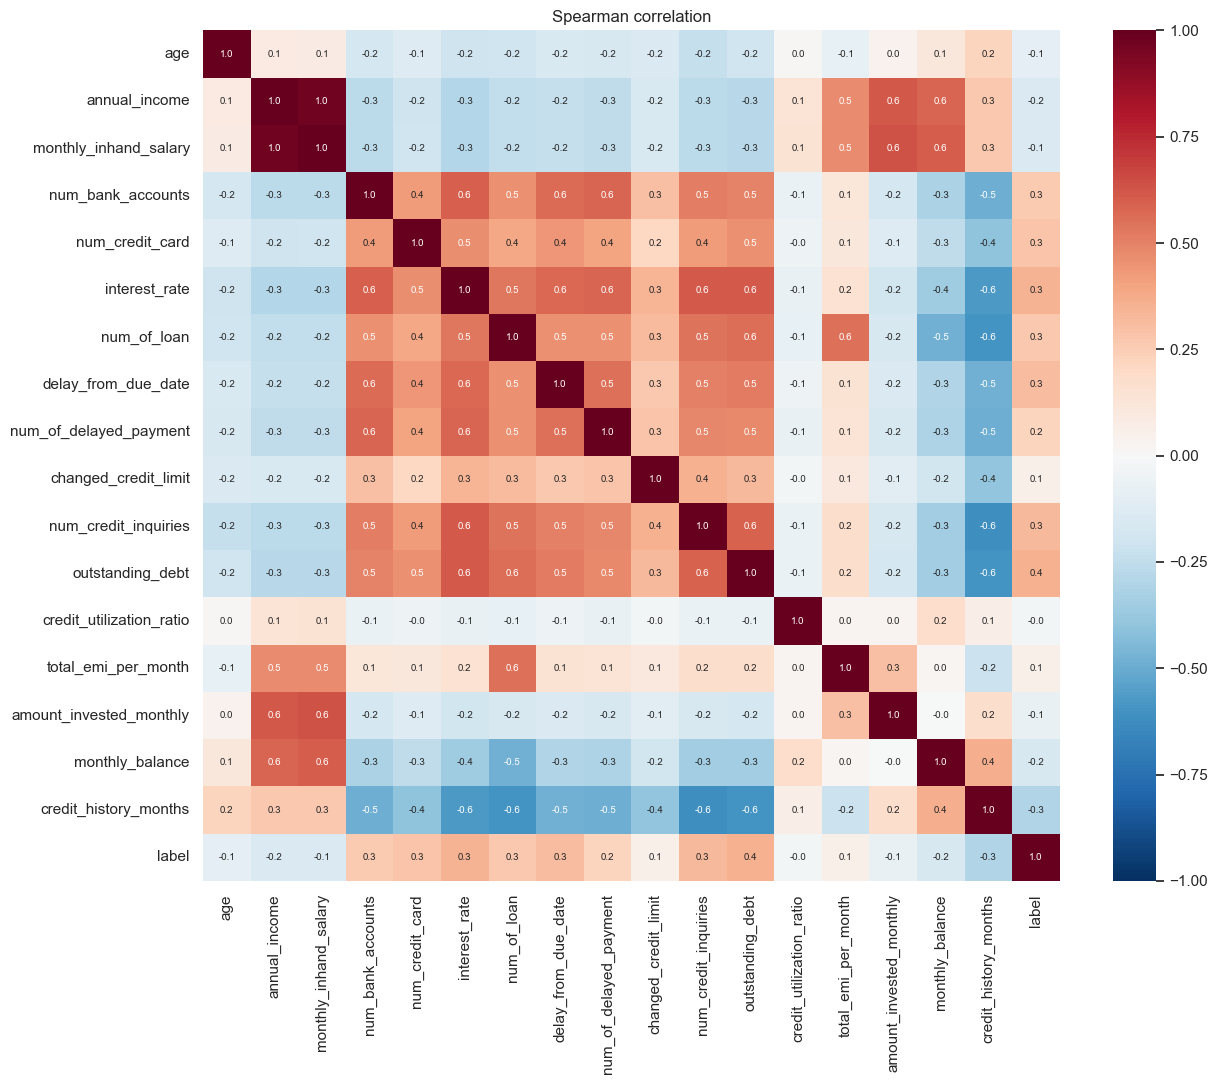

most correlated feature pairs:
annual_income          monthly_inhand_salary      0.975
monthly_inhand_salary  amount_invested_monthly    0.637
annual_income          amount_invested_monthly    0.622
num_credit_inquiries   credit_history_months     -0.618
interest_rate          outstanding_debt           0.613
                       num_credit_inquiries       0.612
monthly_inhand_salary  monthly_balance            0.602
outstanding_debt       credit_history_months     -0.596
num_of_loan            credit_history_months     -0.596
num_bank_accounts      interest_rate              0.594
num_credit_inquiries   outstanding_debt           0.586
annual_income          monthly_balance            0.586
num_bank_accounts      num_of_delayed_payment     0.586
interest_rate          num_of_delayed_payment     0.579
                       credit_history_months     -0.578
                       delay_from_due_date        0.570
num_bank_accounts      delay_from_due_date        0.566
num_of_loan      

In [ ]:
corr = df[NUMERIC + ['label']].corr(method='spearman')
plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f', annot_kws={'size': 7})
plt.title('Spearman correlation'); plt.tight_layout(); plt.show()

pairs = corr.drop(index='label', columns='label').where(np.triu(np.ones(corr.shape[0] - 1, bool), 1)).stack()
print('most correlated feature pairs:'); print(pairs[pairs.abs() > 0.5].sort_values(key=abs, ascending=False).round(3).to_string())

## 9. Clickstream features (`fe_1` … `fe_20`)
Only the loan-start month is in gold. Analysed on rows where it is present.

In [ ]:
cs = df[df['fe_1'].notna()]
print('rows with clickstream:', len(cs), f"| default rate {cs['label'].mean():.3f}")
uni_fe = uni_auc(FE)
uni_fe.round(3).T

rows with clickstream: 8974 | default rate 0.289


,fe_10,fe_5,fe_4,fe_9,fe_3,fe_8,fe_2,fe_7,fe_1,fe_11,fe_14,fe_18,fe_6,fe_20,fe_13,fe_16,fe_15,fe_19,fe_12,fe_17
auc,0.423,0.568,0.553,0.448,0.55,0.462,0.53,0.48,0.509,0.491,0.491,0.508,0.492,0.505,0.496,0.503,0.503,0.502,0.499,0.499
strength,0.077,0.068,0.053,0.052,0.05,0.038,0.03,0.02,0.009,0.009,0.009,0.008,0.008,0.005,0.004,0.003,0.003,0.002,0.001,0.001
n,8974.000,8974.000,8974.000,8974.000,8974.00,8974.000,8974.00,8974.00,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000,8974.000
median_label0,126.000,101.000,100.000,117.000,98.00,113.000,100.00,111.00,103.000,101.000,101.000,104.000,101.000,99.000,103.000,99.000,99.000,99.000,101.000,101.000
median_label1,100.000,126.000,119.000,99.000,115.00,101.000,113.00,105.00,104.000,97.000,96.000,104.000,98.000,98.000,101.000,99.000,100.000,100.000,102.000,100.000


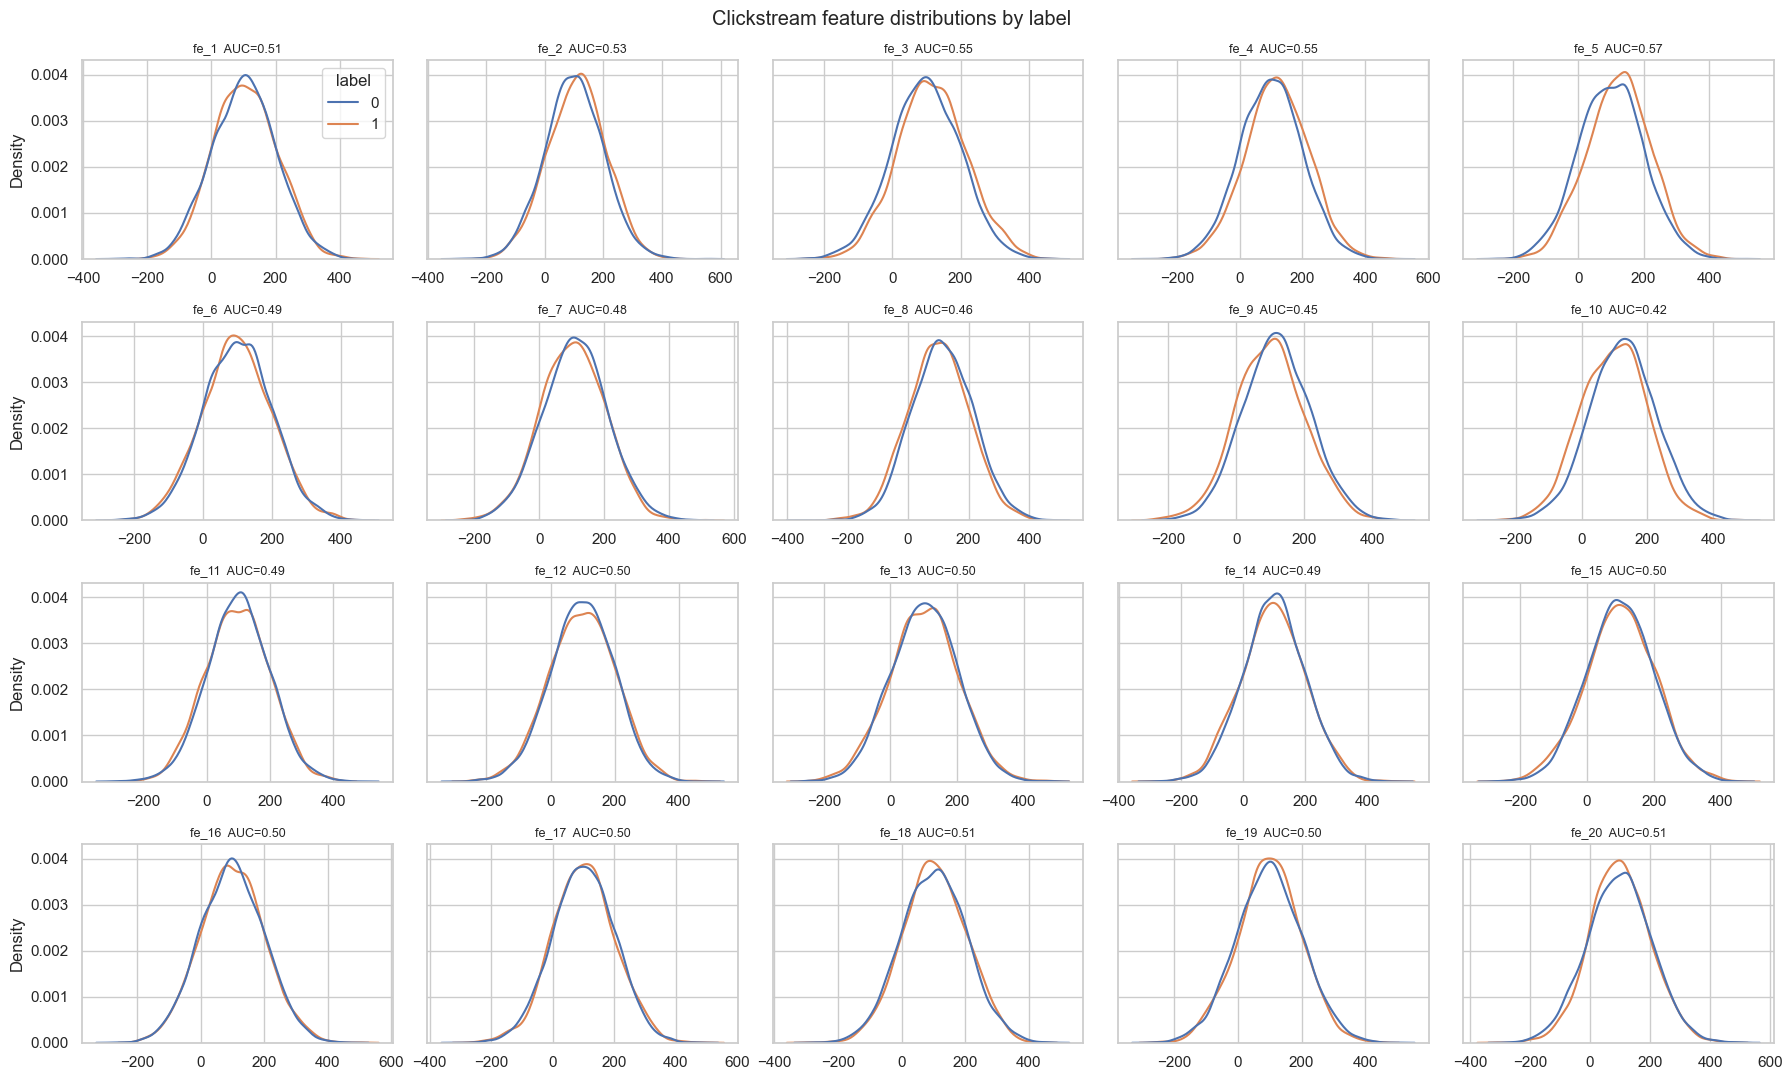

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(18, 11), sharey=True)
for ax, c in zip(axes.flat, FE):
    sns.kdeplot(data=cs, x=c, hue='label', common_norm=False, ax=ax, legend=ax is axes.flat[0])
    ax.set_title(f"{c}  AUC={uni_fe.loc[c, 'auc']:.2f}", fontsize=9); ax.set_xlabel('')
plt.suptitle('Clickstream feature distributions by label'); plt.tight_layout(); plt.show()

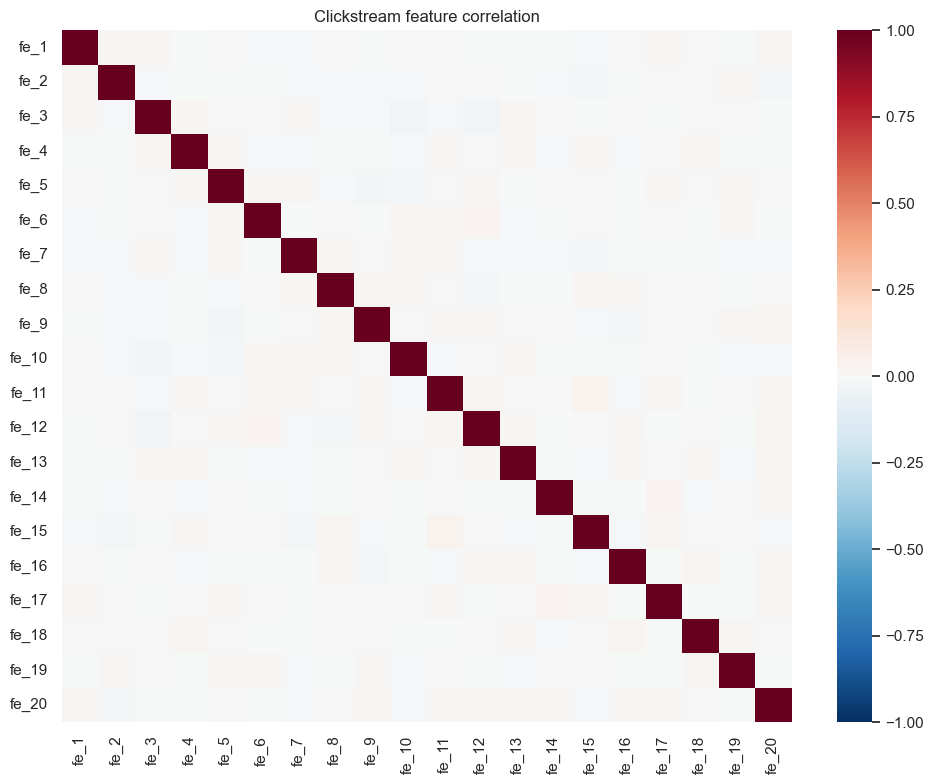

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cs[FE].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Clickstream feature correlation'); plt.tight_layout(); plt.show()

## 10. Stability over time
Monthly **mean ± 95% CI** of the strongest features by loan-start month. The dashed line is the overall mean. A band that wanders inside the noise means no drift.

Means are used instead of medians because integer features (`num_credit_card` = 5 or 6) make monthly medians jump in whole steps. That looks like ±20% but is only a one-unit move. The p-value is a Spearman trend test on the monthly means. Formal drift against the training baseline (CSI) is in `model_training.ipynb` §10.

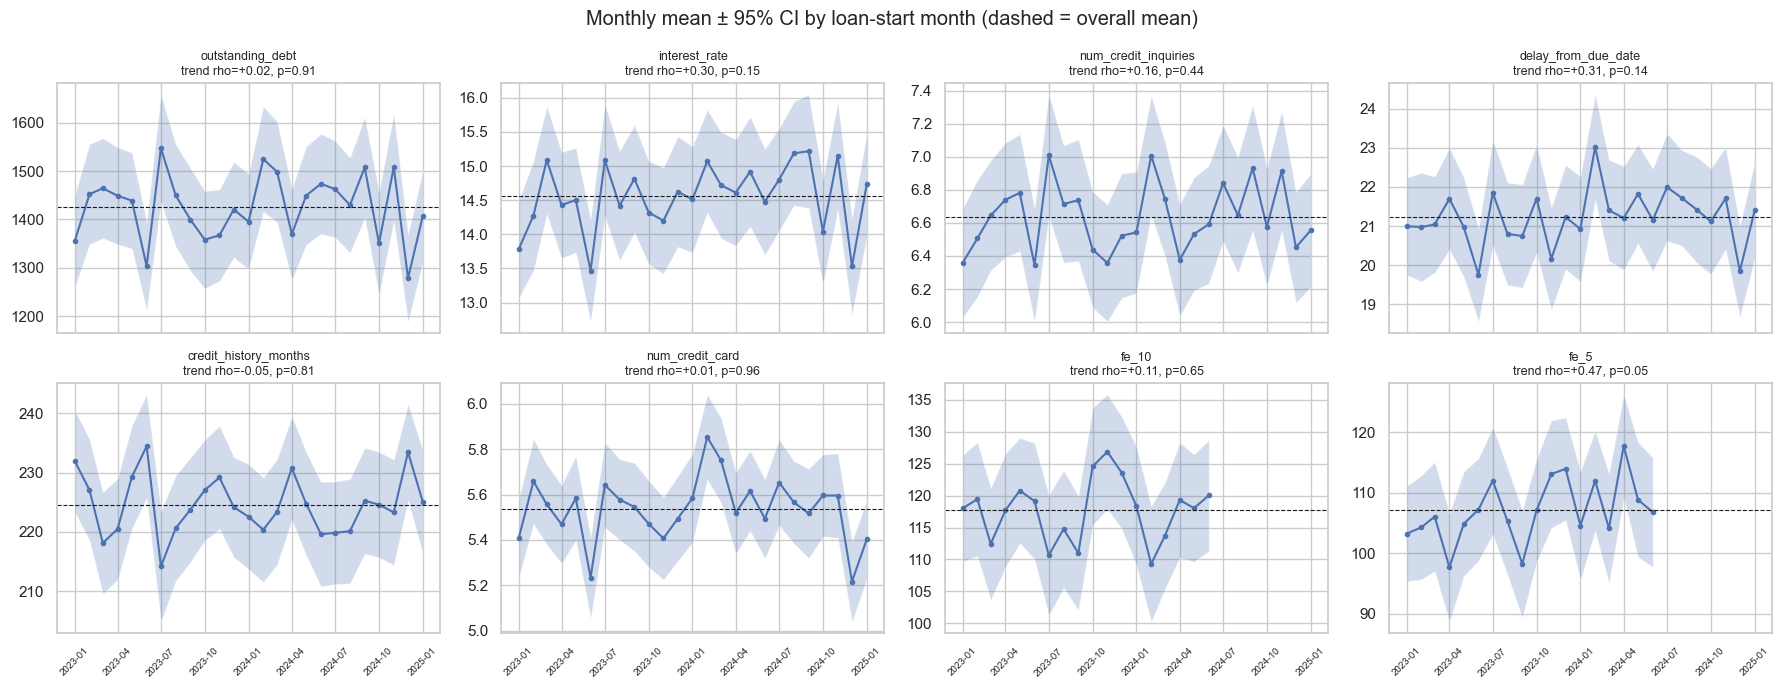

In [ ]:
from scipy.stats import spearmanr

track = list(uni_num.index[:6]) + list(uni_fe.index[:2])
g = df.groupby(df['snapshot_date'].dt.to_period('M').dt.to_timestamp())[track]
mean, ci = g.mean(), 1.96 * g.sem()

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, c in zip(axes.flat, track):
    s = mean[c].dropna()
    ax.plot(s.index, s, 'o-', ms=3)
    ax.fill_between(s.index, (s - ci[c]).loc[s.index], (s + ci[c]).loc[s.index], alpha=0.25)
    ax.axhline(df[c].mean(), color='k', ls='--', lw=0.8)
    rho, p = spearmanr(range(len(s)), s)
    ax.set_title(f'{c}\ntrend rho={rho:+.2f}, p={p:.2f}', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle('Monthly mean ± 95% CI by loan-start month (dashed = overall mean)'); plt.tight_layout(); plt.show()

## 12. Binned features
Business-style bands for the features where the risk curve has steps or bends. The edges were set where the decile plots in §5 change level. `model_training.ipynb` §3c uses the same spec.

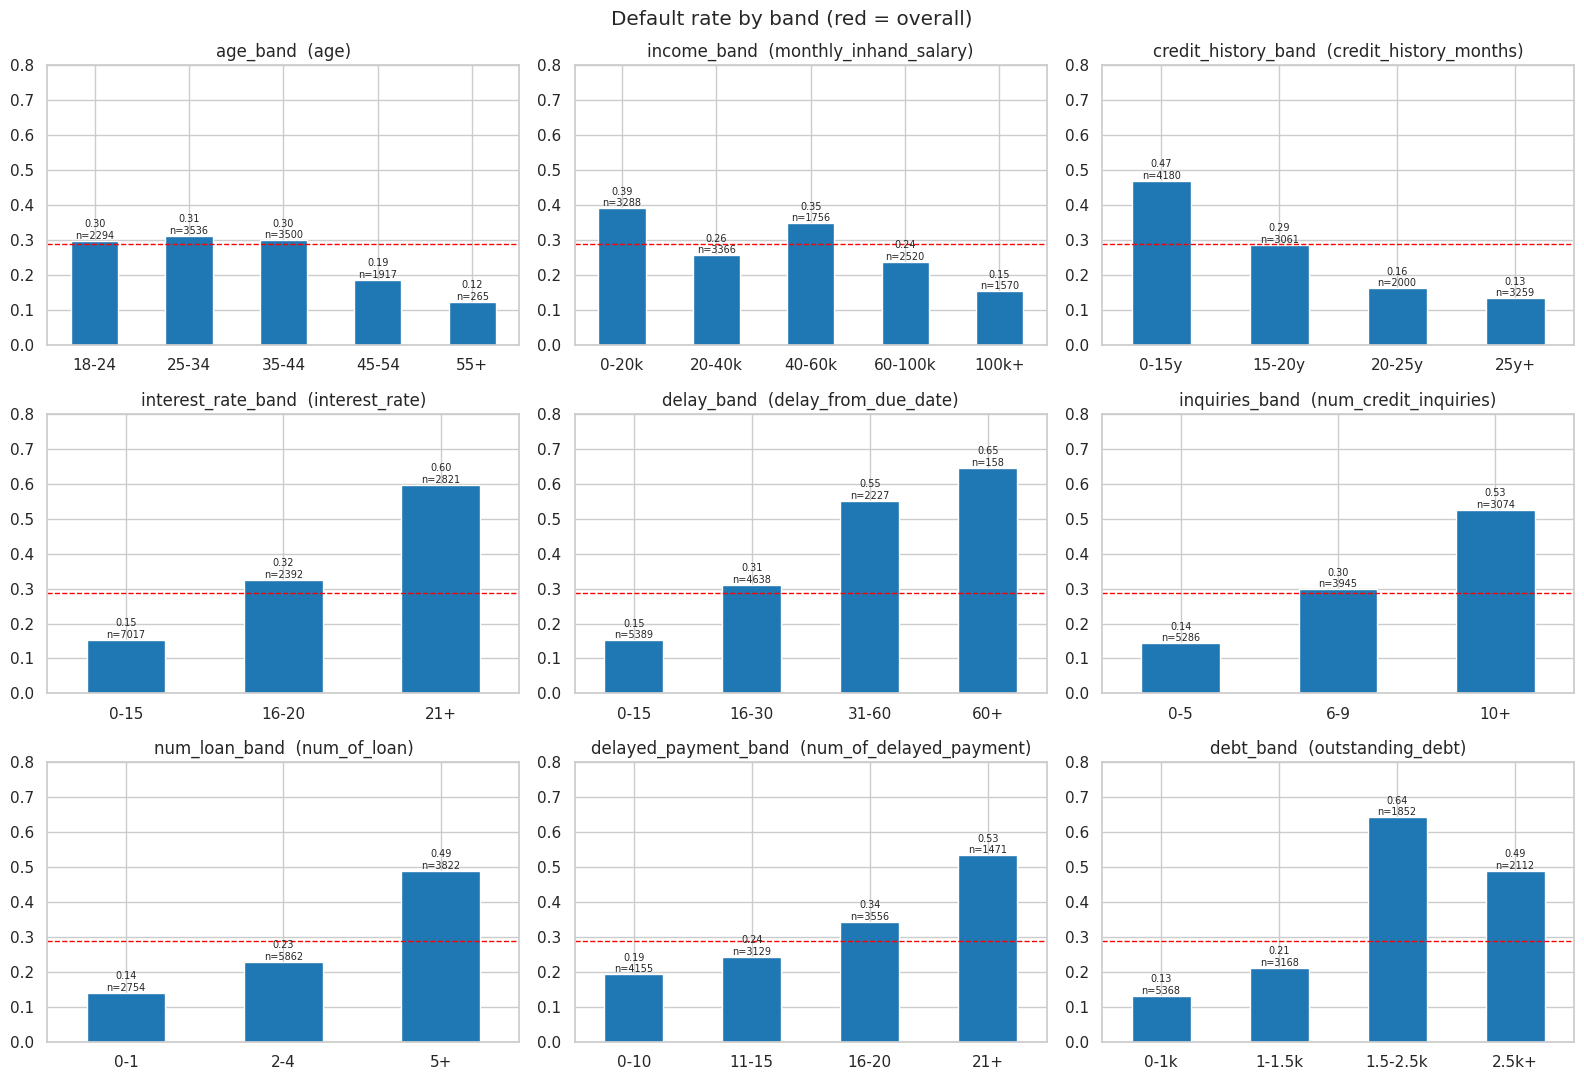

In [13]:
inf = np.inf
# name -> (source column, edges, labels); right-closed bins, NaN stays NaN and gets its own dummy
BANDS = {
    'age_band':             ('age', [-inf, 17, 24, 34, 44, 54, inf], ['0-17', '18-24', '25-34', '35-44', '45-54', '55+']),
    'income_band':          ('monthly_inhand_salary', [-inf, 20e3, 40e3, 60e3, 100e3, inf], ['0-20k', '20-40k', '40-60k', '60-100k', '100k+']),
    'credit_history_band':  ('credit_history_months', [-inf, 180, 240, 300, inf], ['0-15y', '15-20y', '20-25y', '25y+']),
    'interest_rate_band':   ('interest_rate', [-inf, 15, 20, inf], ['0-15', '16-20', '21+']),
    'delay_band':           ('delay_from_due_date', [-inf, 15, 30, 60, inf], ['0-15', '16-30', '31-60', '60+']),
    'inquiries_band':       ('num_credit_inquiries', [-inf, 5, 9, inf], ['0-5', '6-9', '10+']),
    'num_loan_band':        ('num_of_loan', [-inf, 1, 4, inf], ['0-1', '2-4', '5+']),
    'delayed_payment_band': ('num_of_delayed_payment', [-inf, 10, 15, 20, inf], ['0-10', '11-15', '16-20', '21+']),
    'debt_band':            ('outstanding_debt', [-inf, 1000, 1500, 2500, inf], ['0-1k', '1-1.5k', '1.5-2.5k', '2.5k+']),
}
# income is banded on annual salary: annual_income is ~128x salary on 178 dirty rows
scale = {'monthly_inhand_salary': 12}
for name, (c, edges, labels) in BANDS.items():
    df[name] = pd.cut(df[c] * scale.get(c, 1), edges, labels=labels)
BAND_COLS = list(BANDS)

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, b in zip(axes.flat, BAND_COLS):
    g = df.groupby(b, observed=True)['label'].agg(['size', 'mean'])
    g['mean'].plot.bar(ax=ax, color='tab:blue')
    ax.axhline(df['label'].mean(), color='red', ls='--', lw=1)
    for x, (n, r) in enumerate(zip(g['size'], g['mean'])):
        ax.text(x, r, f'{r:.2f}\nn={n}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{b}  ({BANDS[b][0]})'); ax.set_xlabel(''); ax.set_ylim(0, 0.8); ax.tick_params(axis='x', rotation=0)
plt.suptitle('Default rate by band (red = overall)'); plt.tight_layout(); plt.show()

## 13. Clickstream aggregation windows
Gold only keeps the loan-start month of clickstream. The full monthly history is in `datamart/silver/clickstream`: 24 months (2023-01 → 2024-12) for 8,974 customers. This section tests whether averaging a customer's history over a window beats the single month.

Window = the `k` months **up to and including** loan start (`months_before` 0 … k-1). Nothing after the loan starts is used.

In [ ]:
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

cs_all = pd.read_parquet('datamart/silver/clickstream')
cs_all['snapshot_date'] = pd.to_datetime(cs_all['snapshot_date'])
print('clickstream', cs_all['snapshot_date'].min().date(), '->', cs_all['snapshot_date'].max().date(),
      '| customers', cs_all['customer_id'].nunique(),
      '| months per customer', cs_all.groupby('customer_id').size().unique())

hist = df[['loan_id', 'customer_id', 'loan_start_date']].merge(cs_all, on='customer_id')
hist['months_before'] = ((hist['loan_start_date'].dt.year - hist['snapshot_date'].dt.year) * 12
                         + hist['loan_start_date'].dt.month - hist['snapshot_date'].dt.month)
oot_start = df['loan_start_date'] >= '2024-07-01'
print('loans starting 2024-07+ whose customer appears in clickstream at all:',
      df.loc[oot_start, 'customer_id'].isin(cs_all['customer_id']).mean())

clickstream 2023-01-01 -> 2024-12-01 | customers 8974 | months per customer [24]


loans starting 2024-07+ whose customer appears in clickstream at all: 0.0


### Why averaging should help: clickstream is mostly monthly noise
* **ICC** is the share of a feature's variance that is *between* customers rather than month-to-month within one customer. A low ICC means one month is a noisy reading of a stable trait.
* **Lag-1 autocorrelation** within a customer is near 0, so consecutive months are close to independent draws. Averaging k of them cuts the noise by √k.

In [ ]:
g = cs_all.groupby('customer_id')[FE]
icc = g.mean().var() / (g.mean().var() + g.var().mean())
lag1 = cs_all.sort_values('snapshot_date').groupby('customer_id')[FE].apply(
    lambda d: d.apply(lambda s: s.autocorr())).mean()
pd.DataFrame({'ICC': icc, 'lag1 autocorr': lag1}).sort_values('ICC', ascending=False).round(3).T

,fe_10,fe_5,fe_4,fe_9,fe_3,fe_8,fe_2,fe_18,fe_19,fe_7,fe_15,fe_13,fe_20,fe_1,fe_17,fe_14,fe_6,fe_11,fe_12,fe_16
ICC,0.051,0.051,0.048,0.047,0.045,0.045,0.042,0.041,0.041,0.041,0.040,0.040,0.040,0.040,0.040,0.040,0.04,0.039,0.039,0.039
lag1 autocorr,-0.043,-0.046,-0.045,-0.049,-0.043,-0.047,-0.041,-0.041,-0.048,-0.040,-0.043,-0.045,-0.043,-0.043,-0.046,-0.047,-0.04,-0.040,-0.046,-0.044


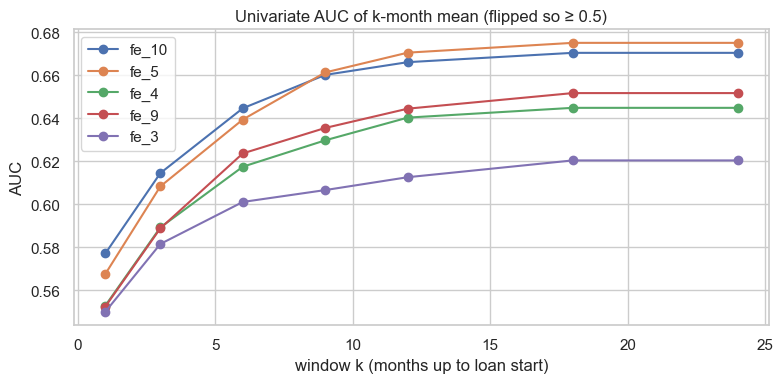

,fe_10,fe_5,fe_4,fe_9,fe_3
1,0.577,0.568,0.553,0.552,0.550
3,0.614,0.608,0.589,0.589,0.581
6,0.645,0.639,0.617,0.624,0.601
9,0.660,0.661,0.630,0.635,0.607
12,0.666,0.670,0.640,0.644,0.613
18,0.670,0.675,0.645,0.652,0.620
24,0.670,0.675,0.645,0.652,0.620


In [ ]:
# univariate AUC of the k-month mean for the 5 strongest features, as k grows
top_fe = list(uni_fe.index[:5])
curve = {}
for k in [1, 3, 6, 9, 12, 18, 24]:
    w = hist[hist['months_before'].between(0, k - 1)].groupby('loan_id')[top_fe].mean()
    y_w = df.set_index('loan_id').loc[w.index, 'label']
    curve[k] = {c: max(roc_auc_score(y_w, w[c]), 1 - roc_auc_score(y_w, w[c])) for c in top_fe}
curve = pd.DataFrame(curve).T
ax = curve.plot(marker='o', figsize=(8, 4), title='Univariate AUC of k-month mean (flipped so ≥ 0.5)')
ax.set_xlabel('window k (months up to loan start)'); ax.set_ylabel('AUC'); plt.tight_layout(); plt.show()
curve.round(3)

### Window comparison in a model
XGBoost with fixed parameters, trained on the train label months (2023-07 → 2024-06), early-stopped on validation (2024-07 → 09), scored on test (2024-10 → 12). Each run uses the same non-clickstream features, and results are the mean of 3 seeds.

* The **`current nb`** row is what `model_training.ipynb` §3 builds today.
* The **`LEAK check`** row averages the 6 months *after* loan start. If clickstream reflected the loan outcome, this row would be far ahead of the pre-start 6-month mean. It isn't, which means every month is just another reading of the same customer trait.

In [ ]:
def window(lo, hi, stats, tag):
    w = hist[hist['months_before'].between(lo, hi)].groupby('loan_id')[FE].agg(stats)
    w.columns = [f'{c}_{s}_{tag}' for c, s in w.columns]
    return w

n_hist = hist[hist['months_before'].between(0, 11)].groupby('loan_id').size().rename('cs_months_12')
WINDOWS = {
    'none': [],
    'loan-start month only (gold)': [window(0, 0, ['mean'], '1')],
    'mean 3m': [window(0, 2, ['mean'], '3')],
    'mean 6m': [window(0, 5, ['mean'], '6')],
    'mean 12m': [window(0, 11, ['mean'], '12')],
    'mean 12m + months of history': [window(0, 11, ['mean'], '12'), n_hist],
    'mean3 + mean6 + std6 (current nb)': [window(0, 2, ['mean'], '3'), window(0, 5, ['mean', 'std'], '6')],
    'LEAK check: mean 6m AFTER start': [window(-6, -1, ['mean'], 'after')],
}

base = pd.get_dummies(df.set_index('loan_id').drop(columns=FE + ['customer_id', 'snapshot_date', 'loan_start_date',
                                                              'label_date', 'label', 'type_of_loan']),
                      dummy_na=True, dtype=float)
y_l = df.set_index('loan_id')['label']
ld = df.set_index('loan_id')['label_date']
tr, va, te = ld <= '2024-06-01', ld.between('2024-07-01', '2024-09-01'), ld.between('2024-10-01', '2024-12-01')

rows = {}
for name, parts in WINDOWS.items():
    Xw = pd.concat([base] + [p.reindex(base.index) for p in parts], axis=1)
    r = []
    for seed in range(3):
        m = XGBClassifier(n_estimators=3000, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.5,
                          min_child_weight=10, eval_metric='aucpr', early_stopping_rounds=200,
                          random_state=seed, n_jobs=-1)
        m.fit(Xw[tr], y_l[tr], eval_set=[(Xw[va], y_l[va])], verbose=False)
        p = m.predict_proba(Xw[te])[:, 1]
        r.append((roc_auc_score(y_l[te], p), average_precision_score(y_l[te], p)))
    r = np.array(r)
    rows[name] = {'clickstream cols': Xw.shape[1] - base.shape[1], 'test AUC': r[:, 0].mean(),
                  'test PR-AUC': r[:, 1].mean(), 'PR-AUC sd': r[:, 1].std()}
win = pd.DataFrame(rows).T
win.round(4)

,clickstream cols,test AUC,test PR-AUC,PR-AUC sd
none,0.0,0.8011,0.6170,0.0036
loan-start month only (gold),20.0,0.8137,0.6309,0.0055
mean 3m,20.0,0.8357,0.6868,0.0022
mean 6m,20.0,0.8694,0.7499,0.0006
mean 12m,20.0,0.9161,0.8198,0.0008
mean 12m + months of history,21.0,0.9193,0.8284,0.0002
mean3 + mean6 + std6 (current nb),60.0,0.8709,0.7511,0.0009
LEAK check: mean 6m AFTER start,20.0,0.8823,0.7702,0.0029


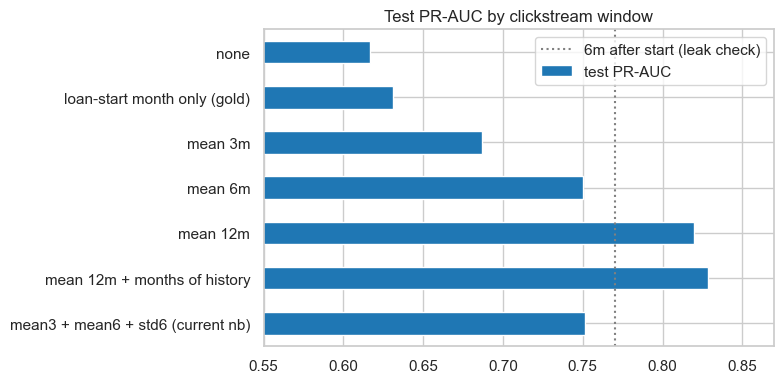

In [ ]:
ax = win.drop(index='LEAK check: mean 6m AFTER start')['test PR-AUC'].plot.barh(figsize=(8, 4), color='tab:blue')
ax.axvline(win.loc['LEAK check: mean 6m AFTER start', 'test PR-AUC'], color='grey', ls=':', label='6m after start (leak check)')
ax.set_xlim(0.55, None); ax.set_title('Test PR-AUC by clickstream window'); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

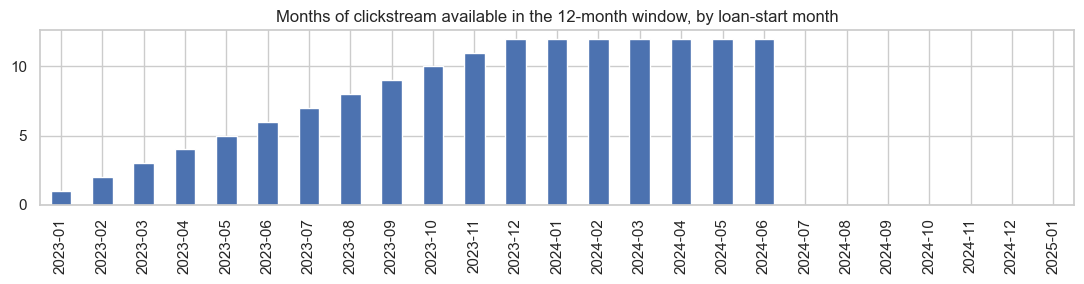

In [ ]:
# history is left-censored: clickstream starts 2023-01, so early loans can't fill a 12-month window
n_hist.reindex(df['loan_id']).fillna(0).groupby(df['loan_start_date'].dt.to_period('M').values).mean() \
      .plot.bar(figsize=(11, 3), title='Months of clickstream available in the 12-month window, by loan-start month')
plt.tight_layout(); plt.show()

## 14. Summary

**Join**: 1:1. Each of the 12,500 labels matches exactly one application-time feature row (one loan per customer, loan starts 2023-01 → 2025-01).

**Target**: 28.8% default overall. Monthly rate moves between 25% and 33% with no trend, so the classes are imbalanced but no time-based reweighting is needed.

**Missing values**
* Clickstream `fe_*` is missing for 28% of rows, all of them loans starting from 2024-07 (clickstream data ends 2024-12). Default rate is the same with or without it, so the missingness comes from time, not from the customer.
* `type_of_loan` missing → 13.7% default vs 30.8%. These customers hold no loans (`num_of_loan` missing/0 behaves the same way), so the missing flag is informative.
* `delay_from_due_date` / `num_of_delayed_payment` missing default much less often (11% / 20%). Keep a missing indicator.
* `credit_mix` is missing for 21%. Treat it as its own category.

**Outliers / data quality**
* `annual_income` max is 23.8M against p99 ≈ 179K (133× p99). This is dirty data and should be capped. `num_of_loan` max is 33 against p99 of 9.
* `annual_income` and `monthly_inhand_salary` have ρ = 0.975, which is close to redundant.
* Otherwise the tails are reasonable (`max / p99` ≈ 1–2).

**Strongest signals (univariate AUC)**
* Numeric: `outstanding_debt` 0.73, `interest_rate` 0.72, `num_credit_inquiries` 0.71, `delay_from_due_date` 0.70, `credit_history_months` 0.31 (longer history = safer), then card, loan and account counts.
* Categorical: `credit_mix` (Cramér's V 0.31) and `payment_of_min_amount` (0.25) are strong, `payment_behaviour` is weak (0.13), and `occupation` carries almost nothing (0.03).
* Loan type: every type defaults at about 36%, so **how many** loans a customer holds matters and **which** kind barely does.
* Clickstream, current month only: weak on its own. The best are `fe_10` (0.42), `fe_5` (0.57), `fe_4`, `fe_9` and `fe_3`, and 12 of the 20 features have |AUC − 0.5| < 0.01. Aggregating over several months (as in `model_training.ipynb`) is where they get useful.

**Bands** (§12): the clearest steps are `interest_rate` (15% default at ≤15 → 60% at 21+), `delay_band` (15% → 65%), `inquiries_band` (14% → 53%), `num_loan_band` (14% → 49%) and `debt_band`, where risk jumps above 1.5K (13% → 64%). Age and history move the other way: 42% for ≤17 and 12% for 55+, 47% for <15y of history and 13% for 25y+. Income is non-monotonic: 40–60K (35%) is riskier than 20–40K (26%).

**Clickstream windows** (§13): clickstream is a stable customer trait under heavy monthly noise. The ICC is about 0.05 and consecutive months are close to uncorrelated, so averaging more months keeps improving the signal. The 12-month mean scores well above the single gold month and the 3m/6m aggregates currently in `model_training.ipynb`. Averaging the 6 months *after* loan start scores about the same as the 6 months before, so this is not leakage. Two limits: (1) no customer whose loan starts from 2024-07 has any clickstream, so a longer window does nothing for OOT; (2) early loans have fewer than 12 months of history (the data starts 2023-01), so a months-of-history count is included.

**Stability**: no feature has a significant monthly trend (all p > 0.1 except `fe_5`, which creeps up ~5%, p ≈ 0.05). Monthly means stay inside their 95% bands around the overall mean, which matches the CSI < 0.1 in `model_training.ipynb`.
